In [21]:
#Подключение библиотек для работы
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression #Линейная регрессия подходит чтобы предсказать конкретное значение цены по четарём признакам.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Для оценки важности признаков использую permutation_importance. Этот метод позволяет проверить, насколько каждый признак важен
#для уже обученной модели.
from sklearn.inspection import permutation_importance

In [3]:
#Загружаем данные
df = pd.read_csv('price_sample.csv')

#Размер таблицы и названия столбцов
print(df.shape)
print(df.columns)
print()

#Основные проверки таблицы
print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()

#Проверка на пропуски и дубликаты
print(df.isnull().sum())
print()
print(df.duplicated().sum())

(10003, 5)
Index(['para1', 'para2', 'para3', 'para4', 'price'], dtype='object')

   para1  para2    para3  para4   price
0      1  662.0   3000.0    3.8   73.49
1      1  340.0   2760.0    9.2  300.00
2      0   16.0   2700.0    3.0  130.00
3      1   17.0  12320.0    6.4  365.00
4      1  610.0   2117.0   10.8  357.50

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB
None

              para1        para2         para3        para4         price
count  10003.000000  9997.000000  10003.000000  9998.000000  10003.000000
mean       1.380986   447.270681   9547.975527     8.458024    433.774924
std        3.500408   220.91380

In [4]:
#Очистка и удаление данных
df.drop_duplicates(inplace = True)

df['para2'] = df['para2'].fillna(df['para2'].median())
df['para4'] = df['para4'].fillna(df['para4'].median())

#Проверка после редактирования данных + просмотр размер изменённой таблицы
print(df.isnull().sum())
print()
print(df.duplicated().sum())
print()
print(df.shape)

para1    0
para2    0
para3    0
para4    0
price    0
dtype: int64

0

(9788, 5)


In [17]:
#Разделяем данные на признаки и целевую переменную
X = df.drop('price', axis=1)
y = df['price']

#Делим данные на тренировочные и тестовые 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Создаём и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

#Получаем предсказания по тестовым данным
y_pred = model.predict(X_test)

#Оценка модели с помощью метрик
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")
#Модель ошибается примерно на 119 единиц цены, также модель объясняет примерно 54% изменений цены. Предсказания модели не являются полностью точными.

MAE: 119.07
MSE: 41063.00
R2: 0.54


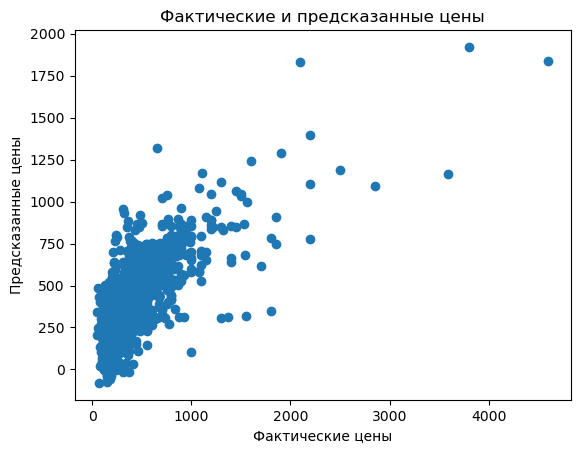

In [20]:
#Визуализация качества модели
plt.scatter(y_test, y_pred)
plt.title("Фактические и предсказанные цены")
plt.xlabel("Фактические цены")
plt.ylabel("Предсказанные цены")
plt.show()

para2    0.527171
para4    0.431744
para1    0.000977
para3    0.000464
dtype: float64


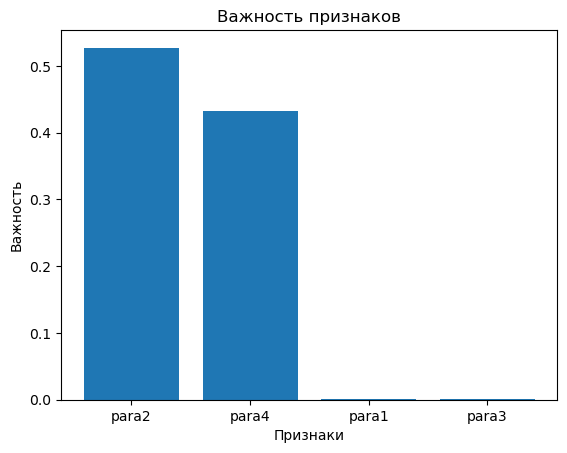

In [24]:
#Для оценки важности признаков использую permutation_importance. Этот метод позволяет проверить, насколько каждый признак важен
#для уже обученной модели.

#Методом перемешиваем значения признаков для проверки насколько после этого изменяется качетсов модели.
importance = permutation_importance(model, X_test, y_test, random_state = 42)

#Создаём Series со средним значением важности каждого признака
feature_importance = pd.Series(importance.importances_mean, index = X.columns)

#Сортируем признаки на убывание
feature_importance = feature_importance.sort_values(ascending = False)
print(feature_importance)
#Видно что самыми важными признаки для модели являются: para2 и para4

#Визуализация важности признаков
plt.bar(feature_importance.index, feature_importance.values)
plt.title("Важность признаков")
plt.xlabel("Признаки")
plt.ylabel("Важность")
plt.show()

para1    0.075224
para2    0.551333
para3    0.359089
para4    0.517948
price    1.000000
Name: price, dtype: float64



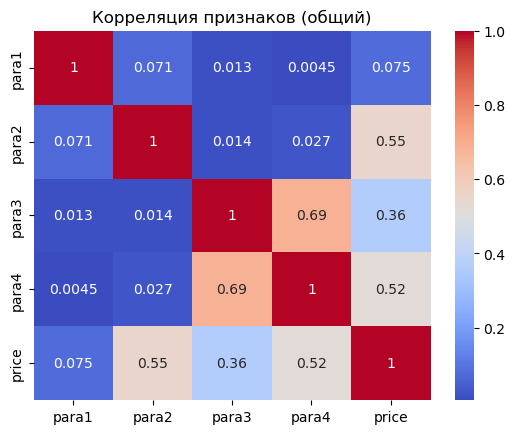

para1    0.075224
para2    0.551333
para3    0.359089
para4    0.517948
Name: price, dtype: float64



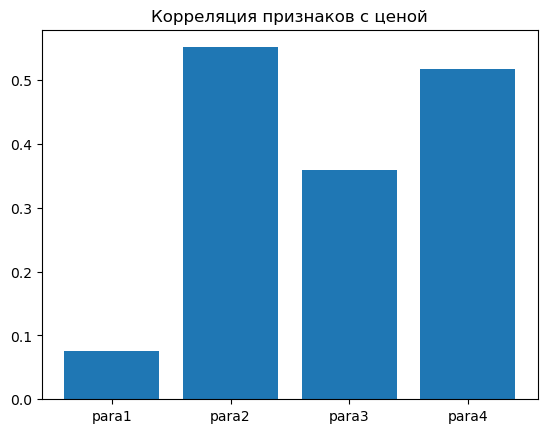

In [10]:
#Просмотр корреляции именно с price
correlation = df.corr()
print(correlation['price'])
print()
#Более всего положительных связей у para2 и para4

#Визуализация для общей корреляции
sns.heatmap(correlation, annot = True, cmap = 'coolwarm')
plt.title("Корреляция признаков (общий)")
plt.show()

#Визуализация для корреляции с ценой
price_correlation = df.corr()['price'].drop('price')
print(price_correlation)
print()

plt.bar(price_correlation.index, price_correlation.values)
plt.title("Корреляция признаков с ценой")
plt.show()